In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
print("Loading dataset...")

df = pd.read_csv("../Module1/raw_metadata.csv")

df.head()

Loading dataset...


,video_id,title,publish_date
0,fPopFeqw5sk,Learn NumPy data types in 8 minutes! 💱,2025-11-21
1,81i_uSX9Vic,Useful NumPy functions you should know! 🎚️,2025-11-12
2,k0D3MQwLn7A,Learn Python iterators in 7 minutes! ➡️,2025-11-10
3,ZBlxaXMN_hU,Learn Python generator expressions in 9 minute...,2025-11-07
4,c9vhHUGdav0,Learn Matplotlib in 1 hour! 📊,2025-10-09


In [3]:
print("Dataset Shape:")
df.shape

Dataset Shape:


(222, 3)

In [4]:
print("Column Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nTotal Rows:", len(df))

Column Names:
Index(['video_id', 'title', 'publish_date'], dtype='str')

Data Types:
video_id        str
title           str
publish_date    str
dtype: object

Total Rows: 222


In [5]:
required_cols = ["video_id", "title", "publish_date"]

for col in required_cols:
    if col not in df.columns:
        raise Exception(f"Missing column: {col}")

print("All required columns exist ✅")

All required columns exist ✅


In [6]:
print("Duplicate video_ids:", df.duplicated(subset="video_id").sum())
print("Duplicate titles:", df.duplicated(subset="title").sum())

Duplicate video_ids: 0
Duplicate titles: 0


In [7]:
df.isnull().sum()

video_id        0
title           0
publish_date    0
dtype: int64

In [8]:
df = df.dropna(subset=["video_id", "title", "publish_date"])
df.shape

(222, 3)

In [9]:
df["publish_date"] = pd.to_datetime(df["publish_date"])

df["year"] = df["publish_date"].dt.year
df["month"] = df["publish_date"].dt.month

df.head()

,video_id,title,publish_date,year,month
0,fPopFeqw5sk,Learn NumPy data types in 8 minutes! 💱,2025-11-21,2025,11
1,81i_uSX9Vic,Useful NumPy functions you should know! 🎚️,2025-11-12,2025,11
2,k0D3MQwLn7A,Learn Python iterators in 7 minutes! ➡️,2025-11-10,2025,11
3,ZBlxaXMN_hU,Learn Python generator expressions in 9 minute...,2025-11-07,2025,11
4,c9vhHUGdav0,Learn Matplotlib in 1 hour! 📊,2025-10-09,2025,10


In [10]:
videos_per_year = df["year"].value_counts().sort_index()
videos_per_year

year
2020    30
2021    57
2022    26
2023    34
2024    52
2025    23
Name: count, dtype: int64

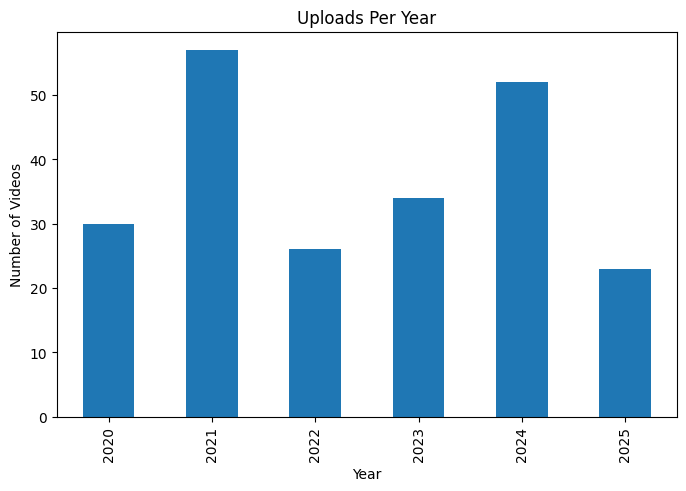

In [11]:
plt.figure(figsize=(8,5))
videos_per_year.plot(kind="bar")

plt.title("Uploads Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")

plt.show()

In [12]:
videos_per_month = df["month"].value_counts().sort_index()
videos_per_month

month
1     10
2      3
3      9
4     12
5     14
6      9
7     29
8     19
9     27
10    26
11    31
12    33
Name: count, dtype: int64

In [13]:
df["title_length"] = df["title"].str.len()

print("Shortest title:")
print(df.loc[df["title_length"].idxmin(), "title"])

print("\nLongest title:")
print(df.loc[df["title_length"].idxmax(), "title"])

print("\nAverage title length:", df["title_length"].mean())

Shortest title:
C# arrays 🚗

Longest title:
Convert decimal to hexadecimal EASY!  #coding #programming #computerscience

Average title length: 32.950450450450454


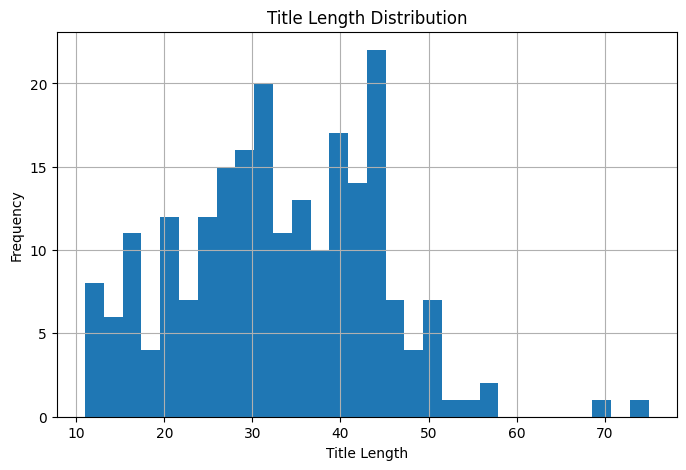

In [14]:
plt.figure(figsize=(8,5))

df["title_length"].hist(bins=30)

plt.title("Title Length Distribution")
plt.xlabel("Title Length")
plt.ylabel("Frequency")

plt.show()

In [15]:
total_unique = df["video_id"].nunique()
date_range = (df["publish_date"].min(), df["publish_date"].max())

print("Total Unique Videos:", total_unique)
print("Date Range:", date_range)

if total_unique < 100:
    print("Dataset too small")
elif total_unique > 350:
    print("Dataset too large")
else:
    print("Dataset within required range ✅")

Total Unique Videos: 222
Date Range: (Timestamp('2020-04-10 00:00:00'), Timestamp('2025-11-21 00:00:00'))
Dataset within required range ✅


In [16]:
df["title"] = (
    df["title"]
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df.head()

,video_id,title,publish_date,year,month,title_length
0,fPopFeqw5sk,Learn NumPy data types in 8 minutes! 💱,2025-11-21,2025,11,38
1,81i_uSX9Vic,Useful NumPy functions you should know! 🎚️,2025-11-12,2025,11,42
2,k0D3MQwLn7A,Learn Python iterators in 7 minutes! ➡️,2025-11-10,2025,11,39
3,ZBlxaXMN_hU,Learn Python generator expressions in 9 minute...,2025-11-07,2025,11,51
4,c9vhHUGdav0,Learn Matplotlib in 1 hour! 📊,2025-10-09,2025,10,29


In [17]:
df.to_csv("cleaned_metadata.csv", index=False)

print("cleaned_metadata.csv saved successfully ✅")

cleaned_metadata.csv saved successfully ✅
